# Global YouTube Statistics — Entrega 2: Análise Exploratória (EDA)

**Disciplina:** Ciência de Dados 2  
**Dataset:** Global YouTube Statistics (995 canais, 28 variáveis originais)  

## Estrutura desta entrega

1. Carregamento dos dados pré-processados (continuação da Entrega 1)
2. Estatísticas descritivas completas
3. Matrizes de correlação — Pearson e Spearman
4. Histogramas e Boxplots das features selecionadas
5. Redução de dimensionalidade: PCA (variância explicada)
6. Visualização 2D: t-SNE e UMAP
7. Análise de impacto das métricas de proximidade (Euclidiana, Manhattan, Cosine)

## 0. Setup e Carregamento

In [ ]:
# ── Instalações necessárias (Colab) ──────────────────────────────────────────
!pip install umap-learn --quiet

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import umap

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


In [ ]:
# ── Carregamento do CSV gerado na Entrega 1 ───────────────────────────────────
# Faça upload do arquivo df_std.csv exportado na Entrega 1.
# Caso prefira recriar, rode todo o notebook da Entrega 1 primeiro.

from google.colab import files
uploaded = files.upload()  # selecione df_std.csv

import io
filename = list(uploaded.keys())[0]
df_std = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'Shape carregado: {df_std.shape}')
df_std.head(3)

Saving df_std.csv to df_std.csv
Shape carregado: (995, 23)


,Youtuber,subscribers,video views,category,Title,uploads,Country,channel_type,country_rank,video_views_for_the_last_30_days,highest_monthly_earnings,subscribers_for_last_30_days,Gross tertiary education enrollment (%),Population,Unemployment rate,subscribers_for_last_30_days_missing,country_rank_missing,channel_age,views_per_subscriber,views_per_upload,earnings_spread,urban_ratio,subscriber_growth_rate
0,T-Series,5.5617,1.5773,Music,T-Series,1.3370,India,Music,1.0000,1.1007,1.1644,1.1494,28.1000,1.4281,5.3600,0,0,1.4742,1.0250,0.2230,1.0709,-1.9333,-0.3067
1,YouTube Movies,4.7485,-9.7756,Film & Animation,youtubemovies,-2.1338,United States,Games,7670.0000,-3.3363,-2.2295,0.2010,88.2000,0.2790,14.7000,1,0,1.4742,-6.1671,-3.7375,-2.2591,0.5374,-0.6678
2,MrBeast,4.6955,0.6726,Entertainment,MrBeast,0.0946,United States,Entertainment,1.0000,0.9801,1.0558,1.7205,88.2000,0.2790,14.7000,0,0,0.1405,-0.7528,0.5194,0.9757,0.5374,1.7147


In [ ]:
# ── Definição das features de análise ────────────────────────────────────────
# Estas são as colunas numéricas APÓS remoção de redundâncias (Entrega 1, seção 3.4).
# Removidas por alta correlação Spearman (|r| >= 0.99):
#   - rank (≈ subscribers), created_year (≈ channel_age),
#   - lowest/highest_monthly_earnings, lowest/highest_yearly_earnings (≈ earnings_spread)
#   - Urban_population (≈ Population)

FEATURES = [
    'subscribers',
    'video views',
    'uploads',
    'video_views_for_the_last_30_days',
    'highest_monthly_earnings',
    'earnings_spread',
    'subscribers_for_last_30_days',
    'Population',
    'channel_age',
    'views_per_subscriber',
    'views_per_upload',
    'urban_ratio',
    'subscriber_growth_rate',
]

# Verificar quais estão presentes
FEATURES = [f for f in FEATURES if f in df_std.columns]
print(f'Features selecionadas ({len(FEATURES)}):', FEATURES)

X = df_std[FEATURES].copy()

# Garantir que não há NaN (já tratado na Entrega 1, mas confirmamos)
print(f'\nNaN por feature:\n{X.isnull().sum()}')

Features selecionadas (13): ['subscribers', 'video views', 'uploads', 'video_views_for_the_last_30_days', 'highest_monthly_earnings', 'earnings_spread', 'subscribers_for_last_30_days', 'Population', 'channel_age', 'views_per_subscriber', 'views_per_upload', 'urban_ratio', 'subscriber_growth_rate']

NaN por feature:
subscribers                         0
video views                         0
uploads                             0
video_views_for_the_last_30_days    0
highest_monthly_earnings            0
earnings_spread                     0
subscribers_for_last_30_days        0
Population                          0
channel_age                         0
views_per_subscriber                0
views_per_upload                    0
urban_ratio                         0
subscriber_growth_rate              0
dtype: int64


---
## 1. Estatísticas Descritivas

**Justificativa:** As estatísticas descritivas revelam a escala, dispersão e assimetria de cada variável,
orientando as decisões subsequentes de normalização, tratamento de outliers e escolha de métricas de distância.
Variáveis com alta assimetria (*skewness* > 1) tendem a distorcer métricas euclidianas e favorecem transformações
log ou normalização robusta.

In [ ]:
desc = X.describe().T
desc['skewness'] = X.skew()
desc['kurtosis'] = X.kurtosis()
desc['cv (%)']   = (X.std() / X.mean().abs() * 100).round(1)  # coeficiente de variação

print('=== Estatísticas Descritivas das Features Selecionadas ===')
display(desc.round(4))

=== Estatísticas Descritivas das Features Selecionadas ===


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv (%)
subscribers,995.0000,0.0000,1.0005,-1.0950,-0.7289,-0.2851,0.4473,5.5617,1.6386,3.5826,29683098038974416.0000
video views,995.0000,-0.0000,1.0005,-9.7756,-0.1476,0.1099,0.3520,1.5773,-7.8628,72.9252,52473491664404032.0000
uploads,995.0000,0.0000,1.0005,-2.3949,-0.4078,0.0885,0.5767,2.3571,-0.5174,0.5526,875651392149742080.0000
video_views_for_the_last_30_days,995.0000,0.0000,1.0005,-3.7740,0.0211,0.2677,0.4796,1.3511,-2.5429,5.9237,138033716989121744.0000
highest_monthly_earnings,995.0000,-0.0000,1.0005,-2.2398,0.0308,0.3682,0.5911,1.2522,-1.5080,0.7863,495944151306049024.0000
earnings_spread,995.0000,-0.0000,1.0005,-2.3389,0.0840,0.3808,0.5720,1.1469,-1.6201,1.0928,322078672974617920.0000
subscribers_for_last_30_days,995.0000,-0.0000,1.0005,-4.5413,-0.0845,0.2010,0.2010,1.7205,-3.4122,11.7870,412071243364581568.0000
Population,995.0000,-0.0000,1.0005,-6.4152,-0.4923,0.2790,0.2790,1.4464,-1.0491,3.3838,96790482033822480.0000
channel_age,995.0000,0.0000,1.0005,-2.0822,-0.7486,-0.0818,0.8073,9.4760,0.8480,6.8844,718483193558764416.0000
views_per_subscriber,995.0000,0.0000,1.0005,-6.1671,-0.3707,0.1946,0.5862,1.9889,-2.9583,14.6999,197329891188674176.0000


In [ ]:
# Resumo de assimetria
skew_vals = X.skew().sort_values(ascending=False)
print('Features com skewness > 1 (distribuição assimétrica positiva):')
print(skew_vals[skew_vals.abs() > 1].to_string())
print('\nFeatures com skewness entre -1 e 1 (aproximadamente simétricas):')
print(skew_vals[skew_vals.abs() <= 1].to_string())

Features com skewness > 1 (distribuição assimétrica positiva):
subscriber_growth_rate              6.4982
subscribers                         1.6386
Population                         -1.0491
urban_ratio                        -1.2354
highest_monthly_earnings           -1.5080
earnings_spread                    -1.6201
views_per_upload                   -2.1121
video_views_for_the_last_30_days   -2.5429
views_per_subscriber               -2.9583
subscribers_for_last_30_days       -3.4122
video views                        -7.8628

Features com skewness entre -1 e 1 (aproximadamente simétricas):
channel_age    0.8480
uploads       -0.5174


---
## 2. Matrizes de Correlação — Pearson e Spearman

**Justificativa da escolha dual:**
- **Pearson** mede correlação linear. Adequada quando as variáveis seguem distribuição normal e a relação é linear.
- **Spearman** mede correlação de postos (monotônica). Robusta a outliers e a distribuições assimétricas — como as encontradas neste dataset (canais como T-Series e MrBeast são outliers extremos).

Dado o alto *skewness* observado, **Spearman é a métrica principal** para decisão de feature selection.
Pearson complementa a análise revelando eventuais relações estritamente lineares.

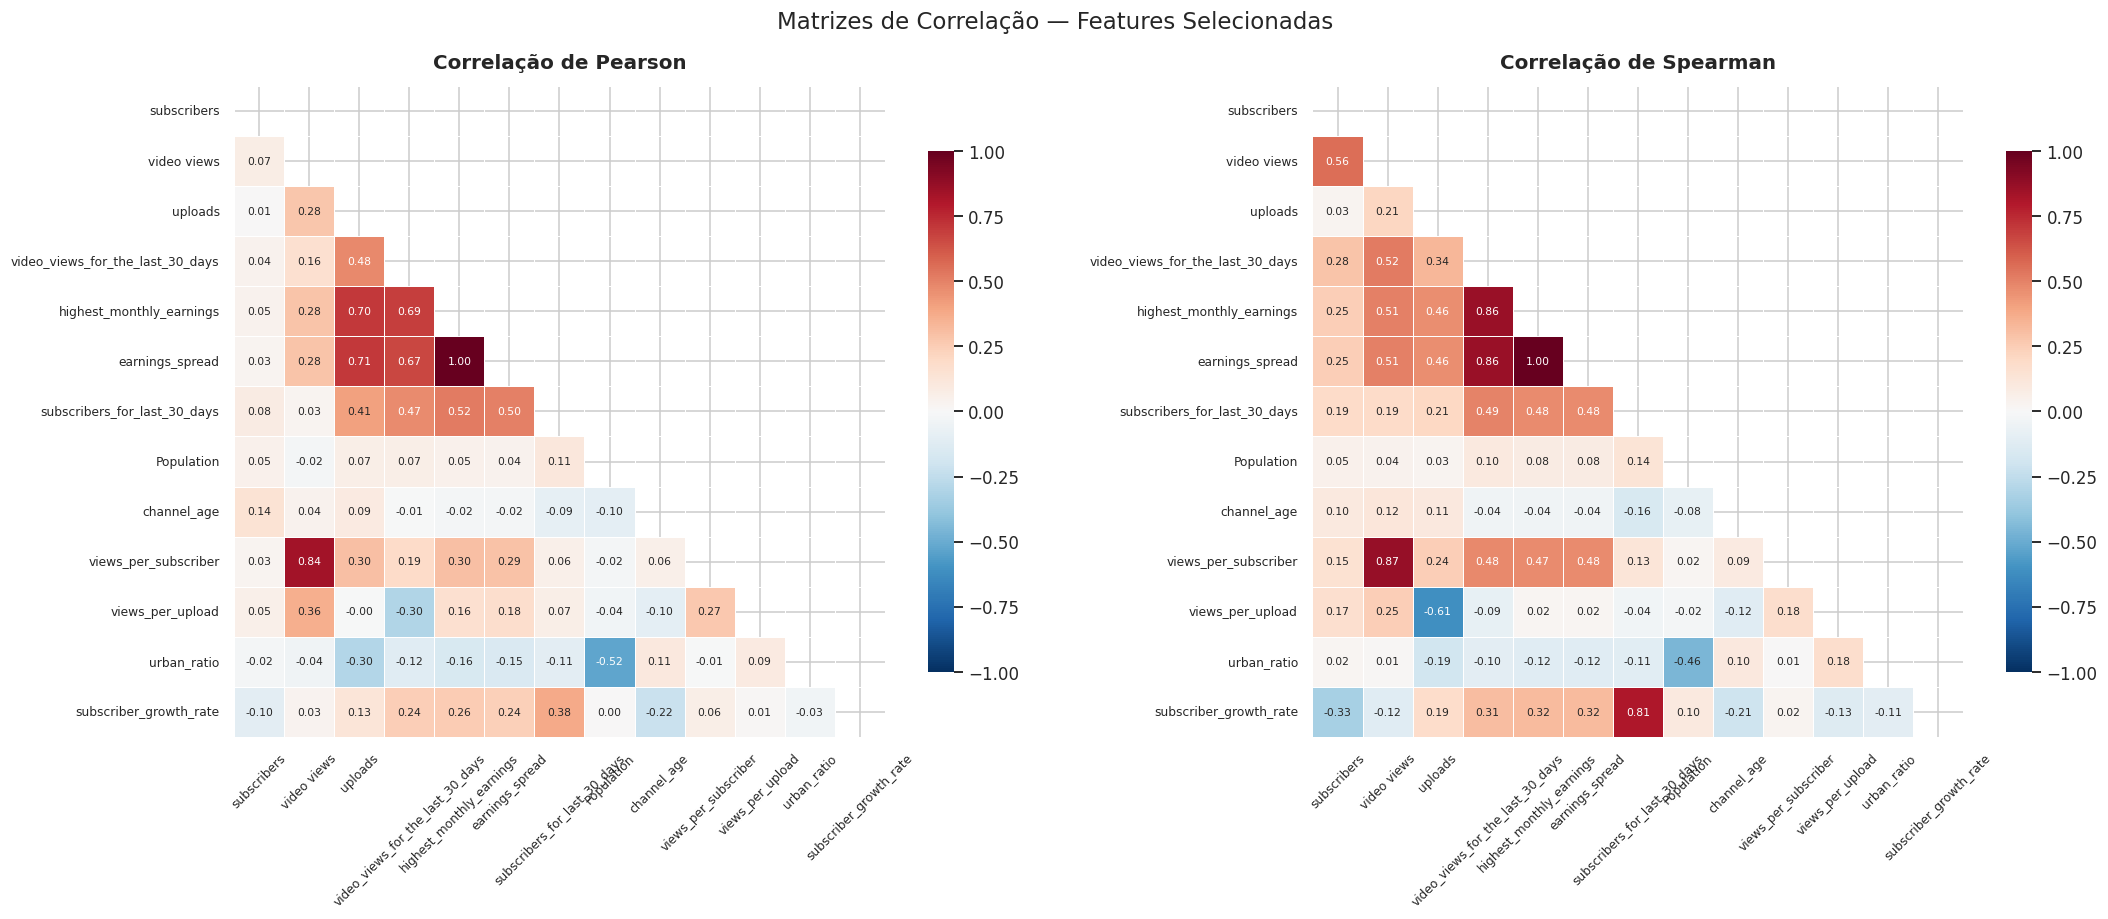

In [ ]:
corr_pearson  = X.corr(method='pearson')
corr_spearman = X.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

for ax, corr, title in zip(
    axes,
    [corr_pearson, corr_spearman],
    ['Correlação de Pearson', 'Correlação de Spearman']
):
    sns.heatmap(
        corr, mask=mask, ax=ax,
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', annot_kws={'size': 7},
        linewidths=0.4, square=True,
        cbar_kws={'shrink': 0.8}
    )
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Matrizes de Correlação — Features Selecionadas', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Diferença entre Pearson e Spearman (|Δr|)
diff = (corr_pearson - corr_spearman).abs()
diff_upper = diff.where(np.triu(np.ones(diff.shape), k=1).astype(bool))
diff_stack = diff_upper.stack().sort_values(ascending=False)

print('Pares com maior divergência entre Pearson e Spearman (|Δr| > 0.1):')
print(diff_stack[diff_stack > 0.1].head(15).to_string())
print('\n→ Divergências altas indicam relação não-linear ou influência de outliers.')

Pares com maior divergência entre Pearson e Spearman (|Δr| > 0.1):
uploads                           views_per_upload                   0.6120
subscribers                       video views                        0.4822
subscribers_for_last_30_days      subscriber_growth_rate             0.4316
video views                       video_views_for_the_last_30_days   0.3634
video_views_for_the_last_30_days  views_per_subscriber               0.2859
uploads                           earnings_spread                    0.2446
                                  highest_monthly_earnings           0.2407
subscribers                       video_views_for_the_last_30_days   0.2394
                                  subscriber_growth_rate             0.2290
video views                       earnings_spread                    0.2257
                                  highest_monthly_earnings           0.2217
subscribers                       earnings_spread                    0.2161
video_views_for_the_l

---
## 3. Histogramas das Features Selecionadas

Os histogramas permitem verificar visualmente a distribuição de cada variável após o pré-processamento.
Distribuições muito assimétricas indicam que algoritmos sensíveis à escala (K-Means com Euclidiana)
podem ser prejudicados.

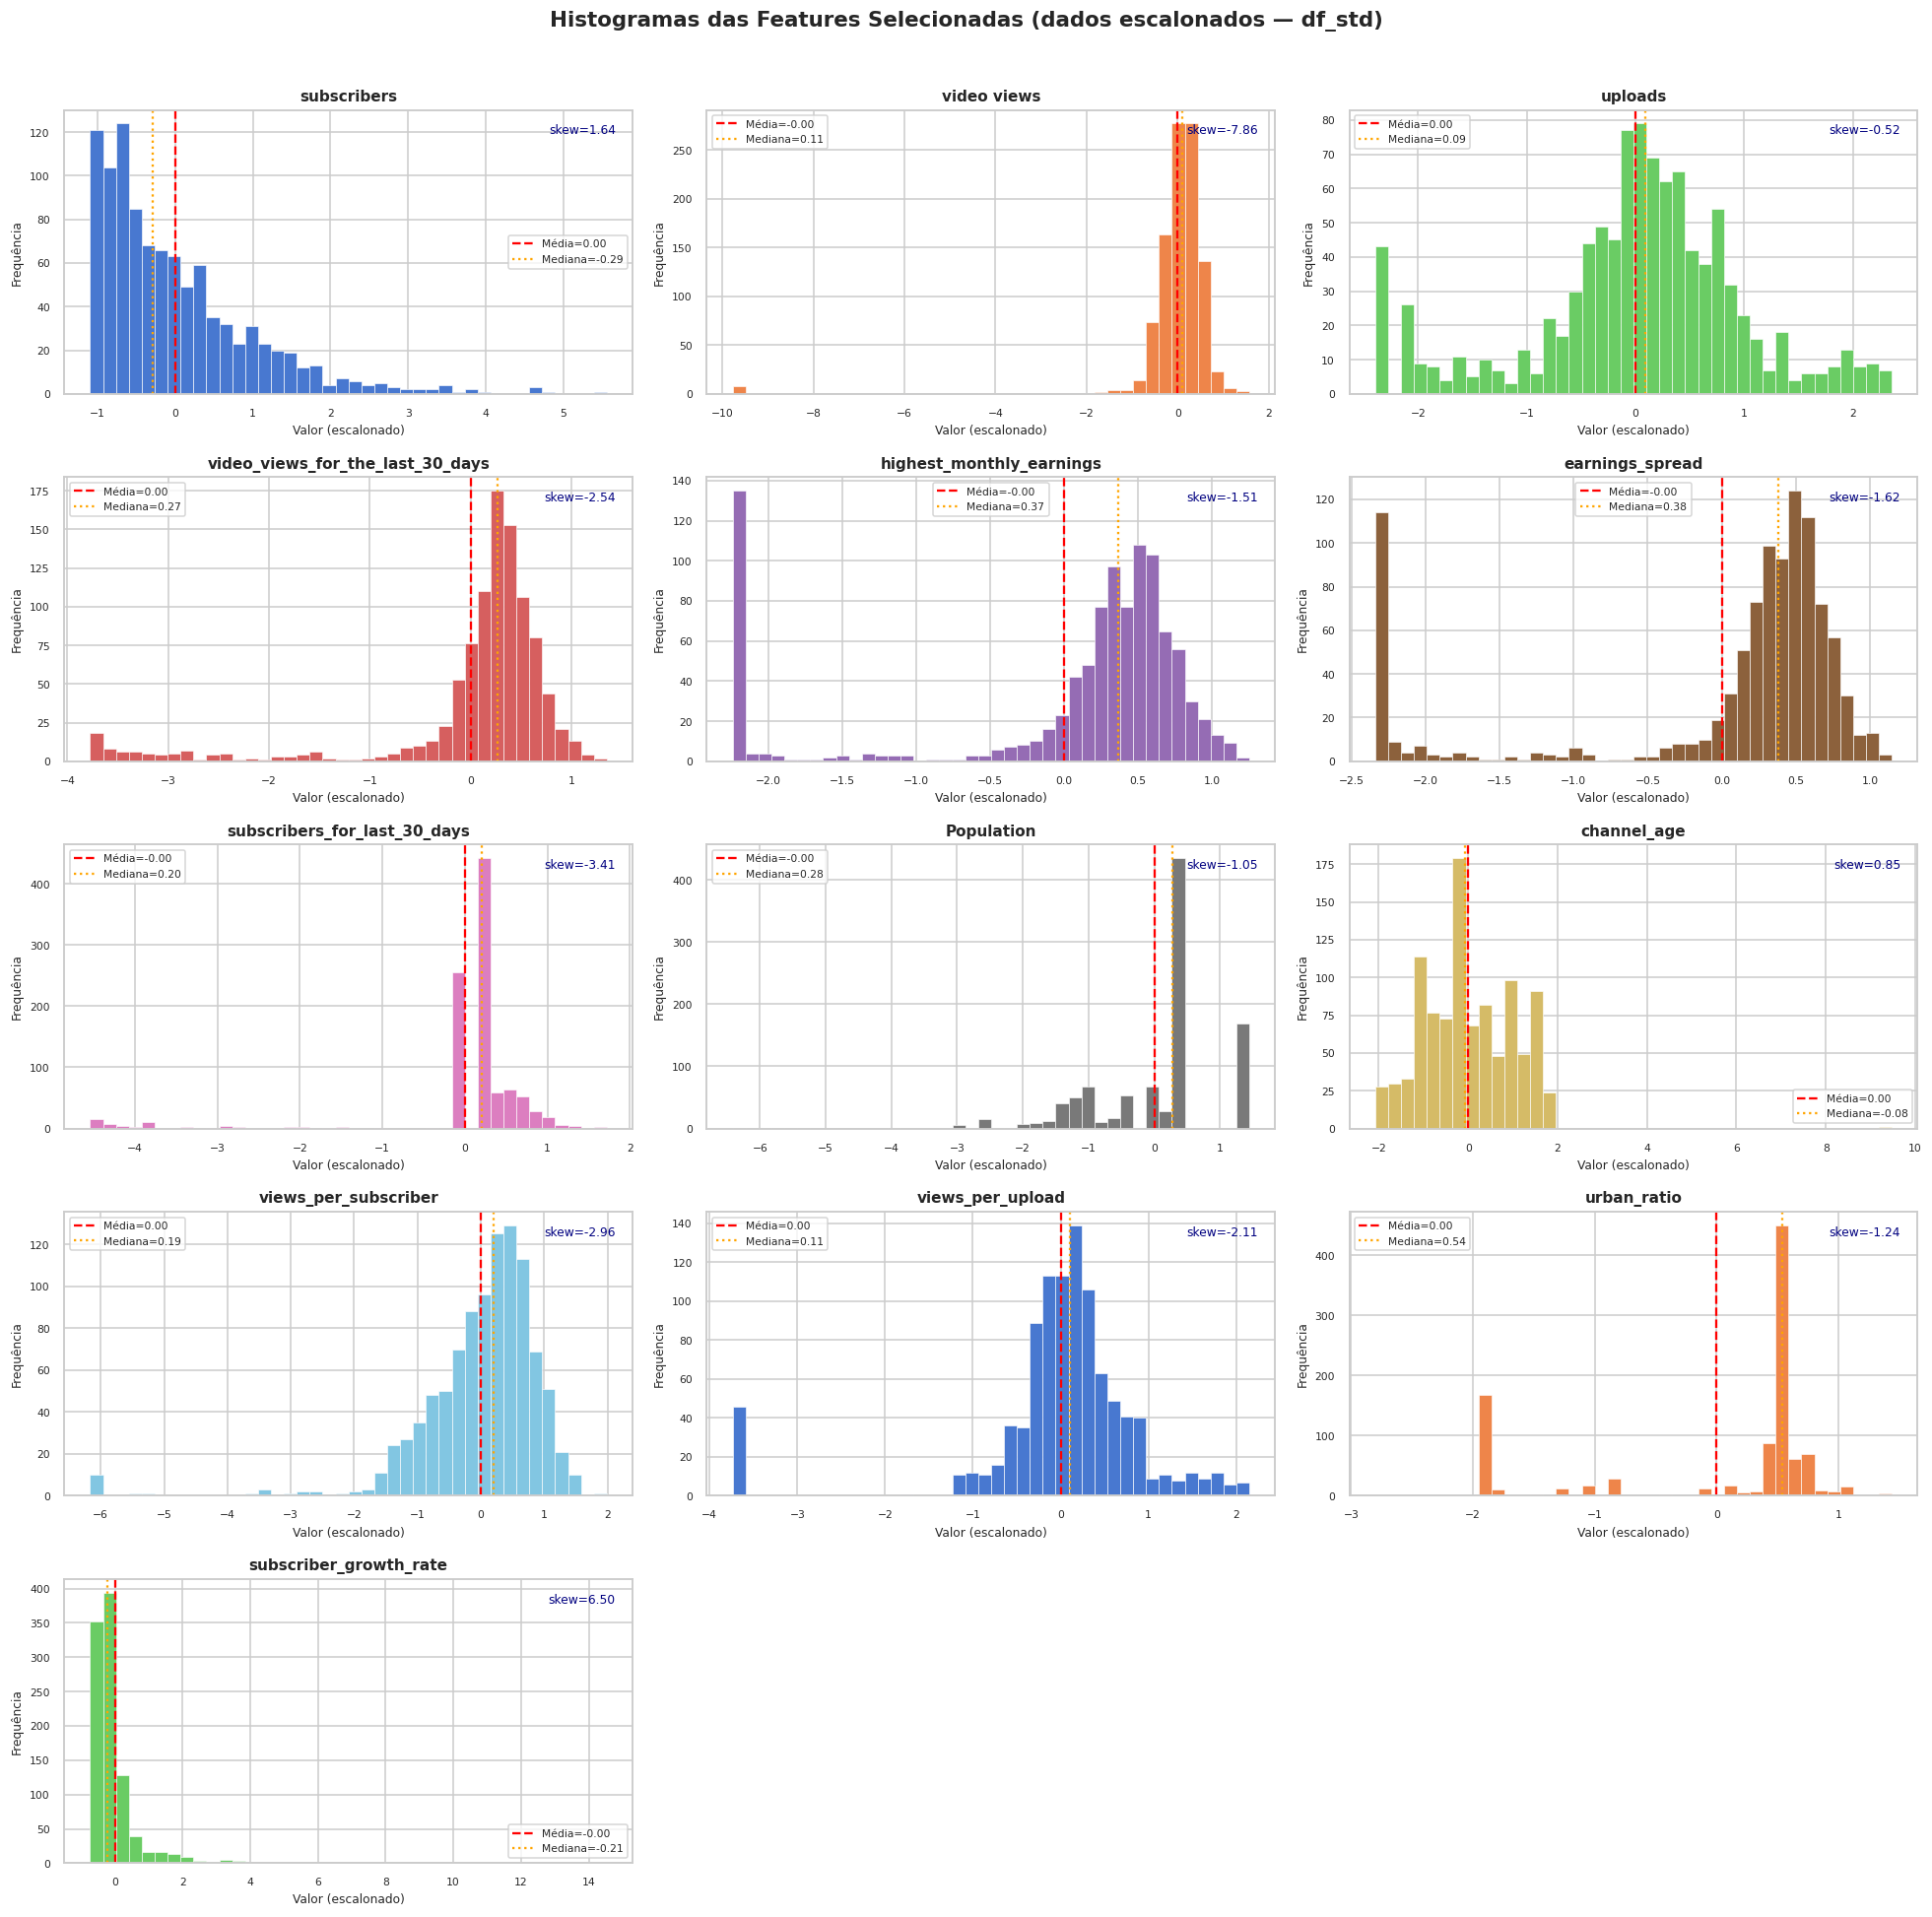

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(FEATURES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

colors = sns.color_palette('muted', len(FEATURES))

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    data = X[feat].dropna()
    ax.hist(data, bins=40, color=colors[i], edgecolor='white', linewidth=0.4)
    ax.axvline(data.mean(),   color='red',    linestyle='--', lw=1.5, label=f'Média={data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle=':',  lw=1.5, label=f'Mediana={data.median():.2f}')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor (escalonado)', fontsize=8)
    ax.set_ylabel('Frequência', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
    skw = data.skew()
    ax.text(0.97, 0.95, f'skew={skw:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='navy')

# Ocultar subplots sobrando
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas das Features Selecionadas (dados escalonados — df_std)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Boxplots das Features Selecionadas

Boxplots complementam os histogramas evidenciando outliers individuais e a dispersão interquartil.
Na Entrega 1, os outliers foram documentados mas preservados (canais reais como T-Series e MrBeast).
Aqui confirmamos visualmente sua localização e quantidade por feature.

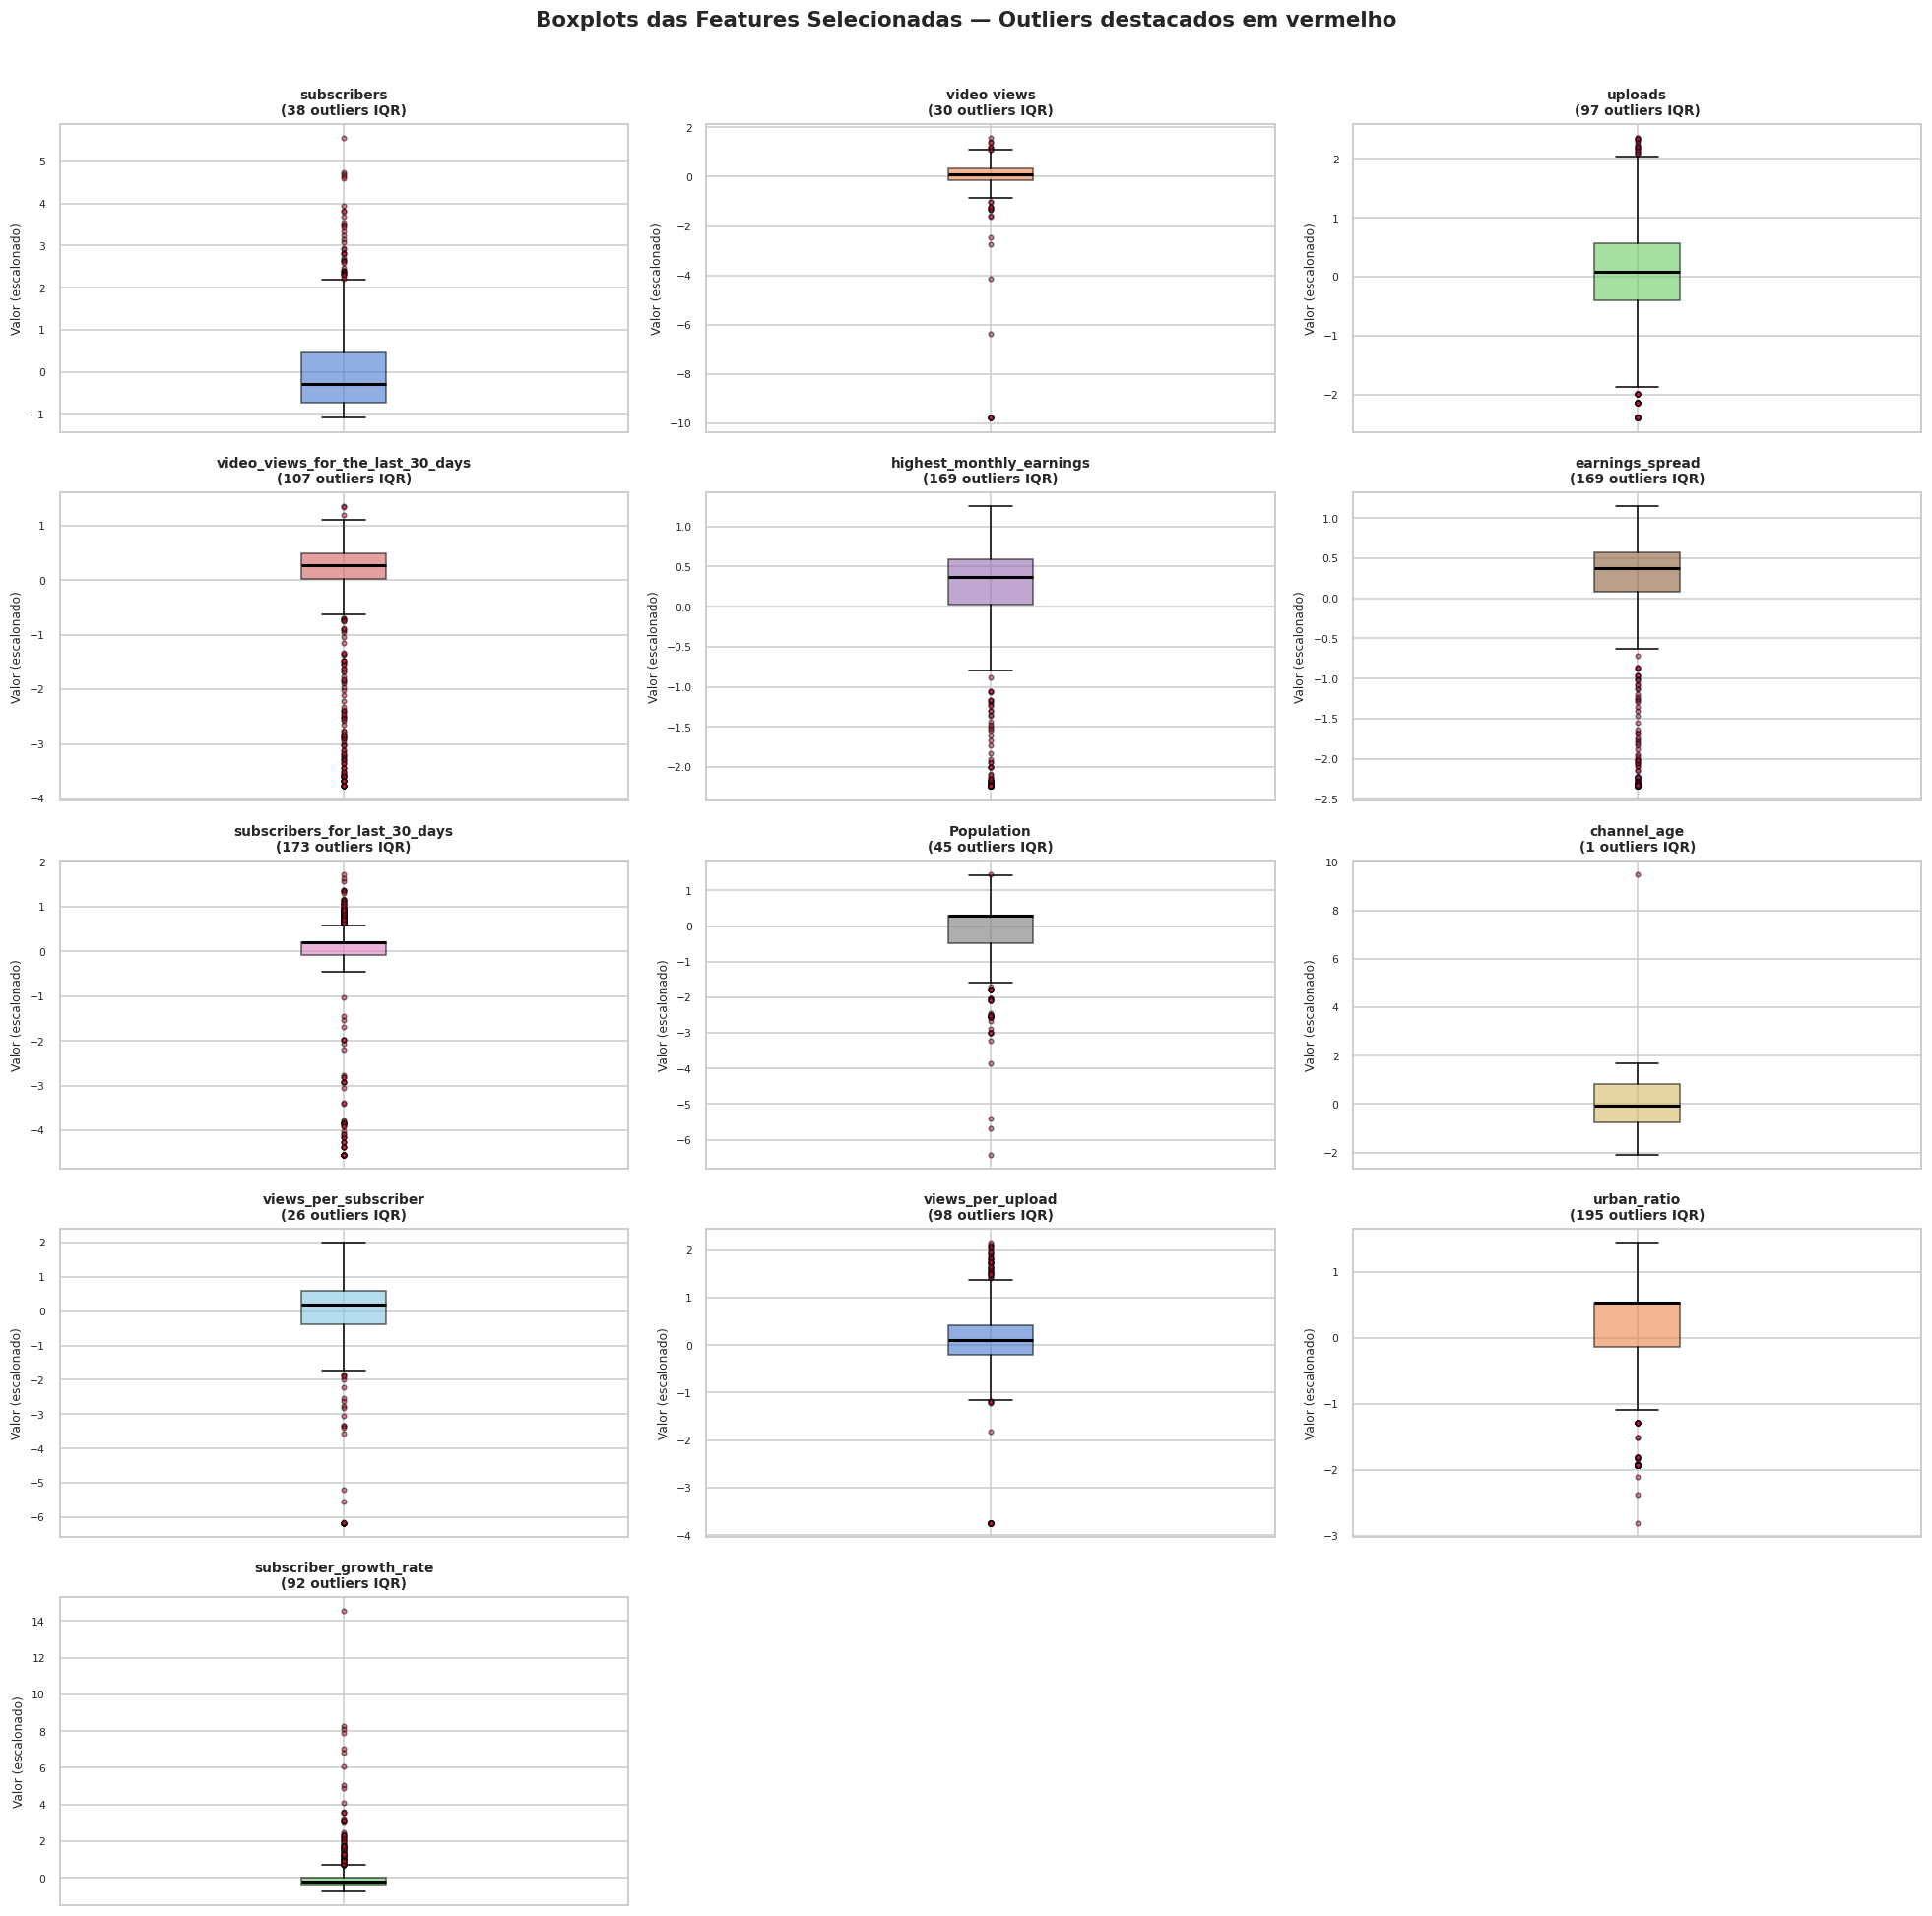

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    data = X[feat].dropna()
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.6),
                    medianprops=dict(color='black', lw=2),
                    flierprops=dict(marker='o', markersize=3,
                                   markerfacecolor='crimson', alpha=0.5))
    # Contagem de outliers IQR
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    ax.set_title(f'{feat}\n({n_out} outliers IQR)', fontsize=9, fontweight='bold')
    ax.set_ylabel('Valor (escalonado)', fontsize=8)
    ax.tick_params(axis='x', labelbottom=False)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots das Features Selecionadas — Outliers destacados em vermelho',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

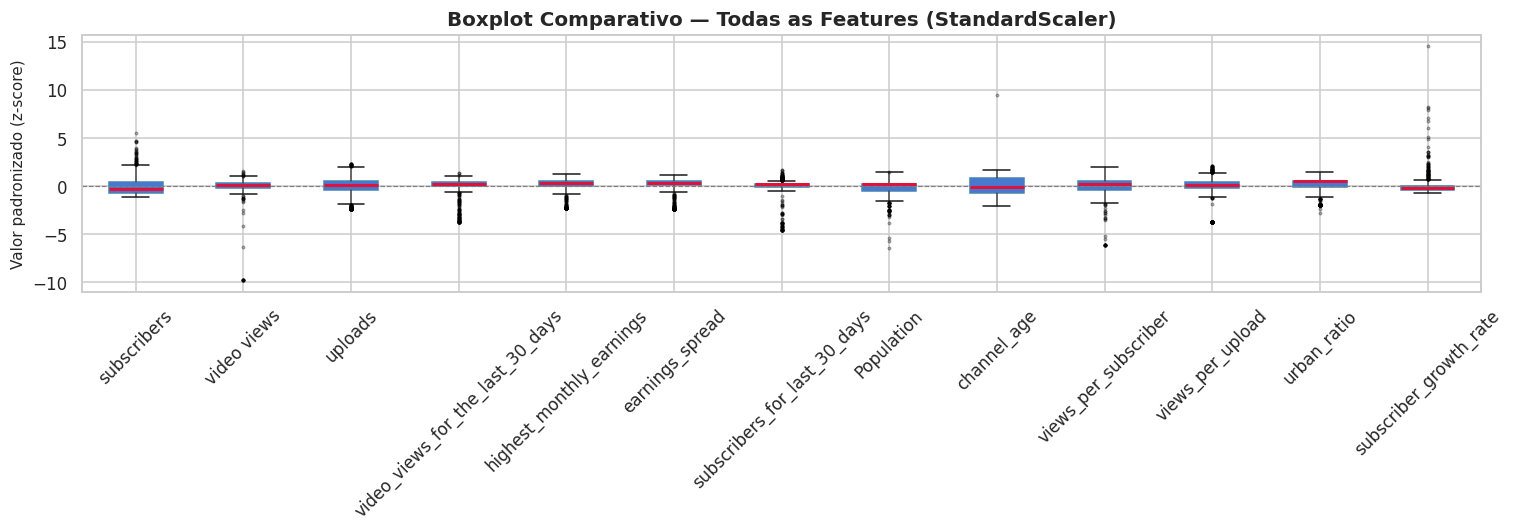

In [ ]:
# Boxplot comparativo unificado (todos no mesmo eixo — possível porque df_std já está padronizado)
fig, ax = plt.subplots(figsize=(14, 5))
X.boxplot(ax=ax, rot=45, patch_artist=True,
          boxprops=dict(color='steelblue'),
          medianprops=dict(color='crimson', lw=2),
          flierprops=dict(marker='.', markersize=3, alpha=0.4))
ax.set_title('Boxplot Comparativo — Todas as Features (StandardScaler)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Valor padronizado (z-score)', fontsize=10)
ax.axhline(0, color='gray', linestyle='--', lw=0.8)
plt.tight_layout()
plt.show()

---
## 5. Redução de Dimensionalidade — PCA

**Justificativa:** O PCA (Principal Component Analysis) é aplicado para:
1. Quantificar a variância explicada por cada componente (guia para decisão de quantos componentes usar na clusterização).
2. Eliminar ruído e multicolinearidade residual entre features.
3. Gerar uma visualização 2D preliminar da estrutura dos dados.

**Critério de retenção:** componentes que, acumulados, explicam ≥ 80% da variância total.

In [ ]:
X.isnull().sum()

,0
subscribers,0
video views,0
uploads,0
video_views_for_the_last_30_days,0
highest_monthly_earnings,0
earnings_spread,0
subscribers_for_last_30_days,0
Population,0
channel_age,0
views_per_subscriber,0


In [ ]:
# PCA com todos os componentes
X_clean = X.fillna(X.median())  # segurança contra NaN residuais

pca_full = PCA(random_state=42)
pca_full.fit(X_clean)

var_ratio  = pca_full.explained_variance_ratio_
var_cumsum = np.cumsum(var_ratio)
n_comp     = len(var_ratio)

print('Variância explicada por componente:')
for i, (v, cv) in enumerate(zip(var_ratio, var_cumsum), 1):
    flag = ' <-- 80%' if abs(cv - 0.80) == min(abs(var_cumsum - 0.80)) else ''
    print(f'  PC{i:02d}: {v*100:5.2f}%  (acumulado: {cv*100:6.2f}%){flag}')

n_80 = np.argmax(var_cumsum >= 0.80) + 1
n_90 = np.argmax(var_cumsum >= 0.90) + 1
print(f'\nComponentes para 80% de variância: {n_80}')
print(f'Componentes para 90% de variância: {n_90}')

Variância explicada por componente:
  PC01: 30.41%  (acumulado:  30.41%)
  PC02: 14.89%  (acumulado:  45.30%)
  PC03: 11.30%  (acumulado:  56.60%)
  PC04: 10.26%  (acumulado:  66.86%)
  PC05:  7.95%  (acumulado:  74.81%)
  PC06:  6.72%  (acumulado:  81.53%) <-- 80%
  PC07:  5.58%  (acumulado:  87.11%)
  PC08:  4.20%  (acumulado:  91.31%)
  PC09:  3.63%  (acumulado:  94.94%)
  PC10:  2.62%  (acumulado:  97.56%)
  PC11:  1.34%  (acumulado:  98.90%)
  PC12:  1.09%  (acumulado:  99.99%)
  PC13:  0.01%  (acumulado: 100.00%)

Componentes para 80% de variância: 6
Componentes para 90% de variância: 8


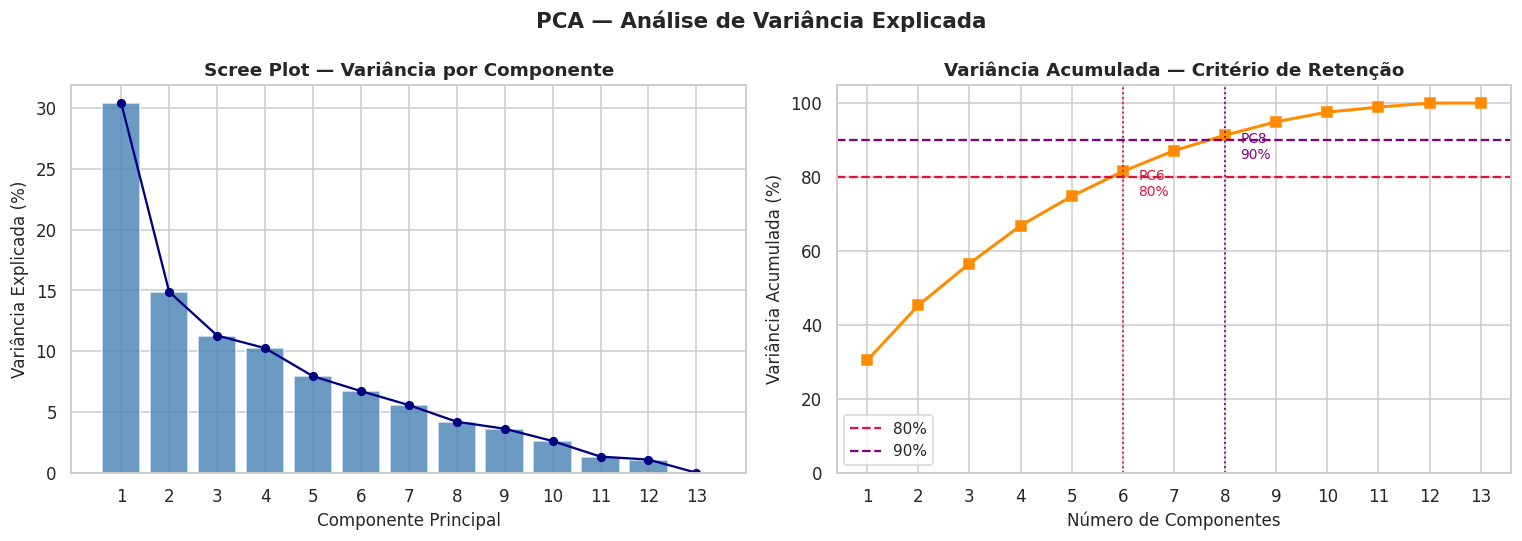


Conclusão: 6 componentes retêm 80% da variância original.
Redução de 13 para 6 features = 54% de compressão.


In [ ]:
# Scree plot (cotovelo) + variância acumulada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax1.bar(range(1, n_comp+1), var_ratio * 100, color='steelblue', alpha=0.8, edgecolor='white')
ax1.plot(range(1, n_comp+1), var_ratio * 100, 'o-', color='navy', markersize=5)
ax1.set_xlabel('Componente Principal', fontsize=11)
ax1.set_ylabel('Variância Explicada (%)', fontsize=11)
ax1.set_title('Scree Plot — Variância por Componente', fontsize=12, fontweight='bold')
ax1.set_xticks(range(1, n_comp+1))

# Variância acumulada
ax2.plot(range(1, n_comp+1), var_cumsum * 100, 's-', color='darkorange',
         markersize=6, linewidth=2)
ax2.axhline(80, color='crimson',  linestyle='--', lw=1.5, label='80%')
ax2.axhline(90, color='purple',   linestyle='--', lw=1.5, label='90%')
ax2.axvline(n_80, color='crimson',  linestyle=':', lw=1.2)
ax2.axvline(n_90, color='purple',   linestyle=':', lw=1.2)
ax2.annotate(f'PC{n_80}\n80%', xy=(n_80, 80), xytext=(n_80+0.3, 75),
             fontsize=9, color='crimson')
ax2.annotate(f'PC{n_90}\n90%', xy=(n_90, 90), xytext=(n_90+0.3, 85),
             fontsize=9, color='purple')
ax2.set_xlabel('Número de Componentes', fontsize=11)
ax2.set_ylabel('Variância Acumulada (%)', fontsize=11)
ax2.set_title('Variância Acumulada — Critério de Retenção', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 105)
ax2.set_xticks(range(1, n_comp+1))
ax2.legend(fontsize=10)

plt.suptitle('PCA — Análise de Variância Explicada', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nConclusão: {n_80} componentes retêm 80% da variância original.')
print(f'Redução de {n_comp} para {n_80} features = {(1 - n_80/n_comp)*100:.0f}% de compressão.')

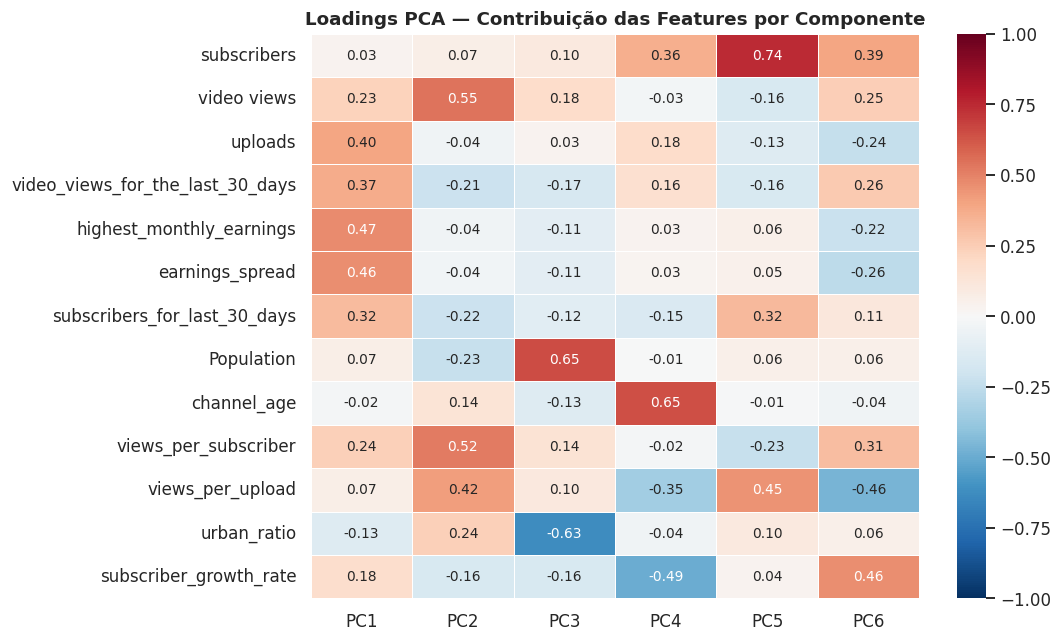


Interpretação dos componentes principais:
  PC1: dominado por ['highest_monthly_earnings', 'earnings_spread', 'uploads']
  PC2: dominado por ['video views', 'views_per_subscriber', 'views_per_upload']
  PC3: dominado por ['Population', 'urban_ratio', 'video views']
  PC4: dominado por ['channel_age', 'subscriber_growth_rate', 'subscribers']
  PC5: dominado por ['subscribers', 'views_per_upload', 'subscribers_for_last_30_days']
  PC6: dominado por ['subscriber_growth_rate', 'views_per_upload', 'subscribers']


In [ ]:
# Loadings — contribuição de cada feature nos primeiros 6 componentes
pca_n = PCA(n_components=n_80, random_state=42)
X_pca = pca_n.fit_transform(X_clean)

loadings = pd.DataFrame(
    pca_n.components_.T,
    index=FEATURES,
    columns=[f'PC{i+1}' for i in range(pca_n.n_components_)]
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(loadings, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, ax=ax)
ax.set_title('Loadings PCA — Contribuição das Features por Componente',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterpretação dos componentes principais:')
for pc in loadings.columns:
    top = loadings[pc].abs().nlargest(3).index.tolist()
    print(f'  {pc}: dominado por {top}')

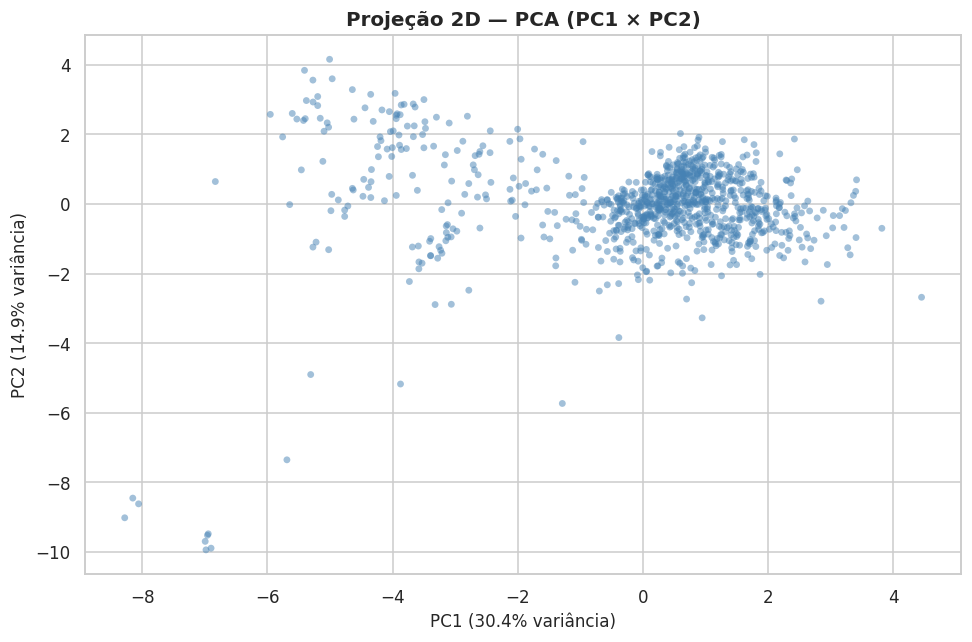


As 2 primeiras componentes explicam 45.3% da variância total.
Observação: agrupamentos visíveis neste espaço sugerem estrutura clusterizável nos dados.


In [ ]:
# Visualização 2D via PCA (PC1 vs PC2)
pca_2d = PCA(n_components=2, random_state=42)
X_pca2 = pca_2d.fit_transform(X_clean)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_pca2[:, 0], X_pca2[:, 1],
                     alpha=0.5, s=20, c='steelblue', edgecolors='none')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variância)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variância)', fontsize=11)
ax.set_title('Projeção 2D — PCA (PC1 × PC2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nAs 2 primeiras componentes explicam {sum(pca_2d.explained_variance_ratio_)*100:.1f}% da variância total.')
print('Observação: agrupamentos visíveis neste espaço sugerem estrutura clusterizável nos dados.')

---
## 6. Visualização 2D — t-SNE e UMAP

**Motivação:** PCA é uma projeção linear. Para capturar estruturas não-lineares (clusters com formatos
irregulares, manifolds curvos), utilizamos métodos não-lineares:

- **t-SNE:** preserva estrutura local; agrupa pontos vizinhos no espaço de alta dimensão.
  Parâmetro-chave: `perplexity` (entre 5–50; valores maiores capturam estrutura mais global).
  **Não** preserva distâncias globais — use apenas para visualização.

- **UMAP:** mais rápido que t-SNE; preserva melhor a estrutura global e local.
  Parâmetro-chave: `n_neighbors` (vizinhança local) e `min_dist` (compactação dos clusters).

**Ambos são usados apenas para visualização**, não como input direto para clusterização.

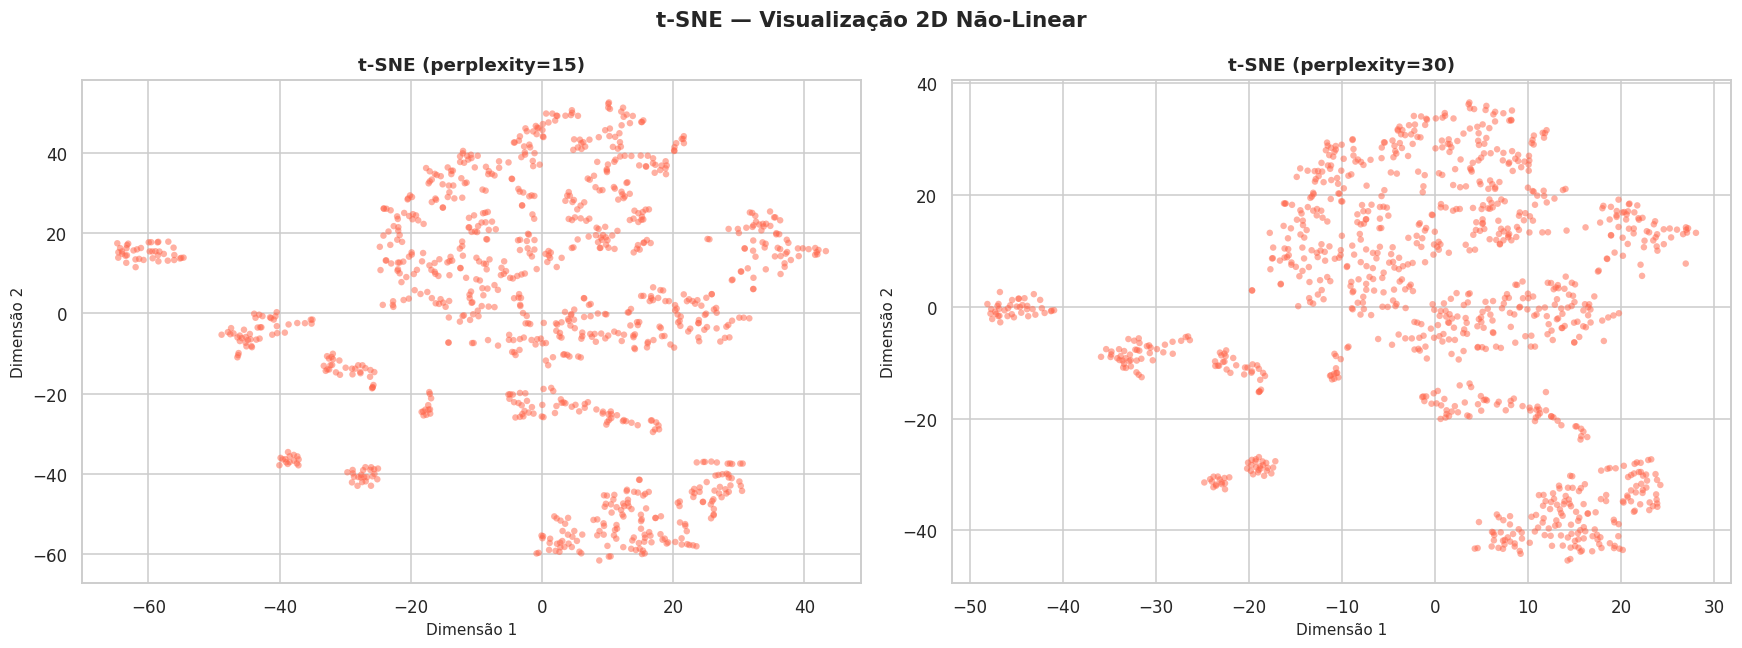

Interpretação: regiões densas no t-SNE indicam canais com perfil similar.
Atenção: distâncias entre clusters no t-SNE NÃO são interpretáveis — apenas a separação interna conta.


In [ ]:
# t-SNE — testamos dois valores de perplexity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, perp in zip(axes, [15, 30]):
    tsne = TSNE(n_components=2, perplexity=perp, n_iter=1000,
                random_state=42, learning_rate='auto', init='pca')
    X_tsne = tsne.fit_transform(X_clean)

    ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
               alpha=0.5, s=18, c='tomato', edgecolors='none')
    ax.set_title(f't-SNE (perplexity={perp})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Dimensão 1', fontsize=10)
    ax.set_ylabel('Dimensão 2', fontsize=10)

plt.suptitle('t-SNE — Visualização 2D Não-Linear', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretação: regiões densas no t-SNE indicam canais com perfil similar.')
print('Atenção: distâncias entre clusters no t-SNE NÃO são interpretáveis — apenas a separação interna conta.')

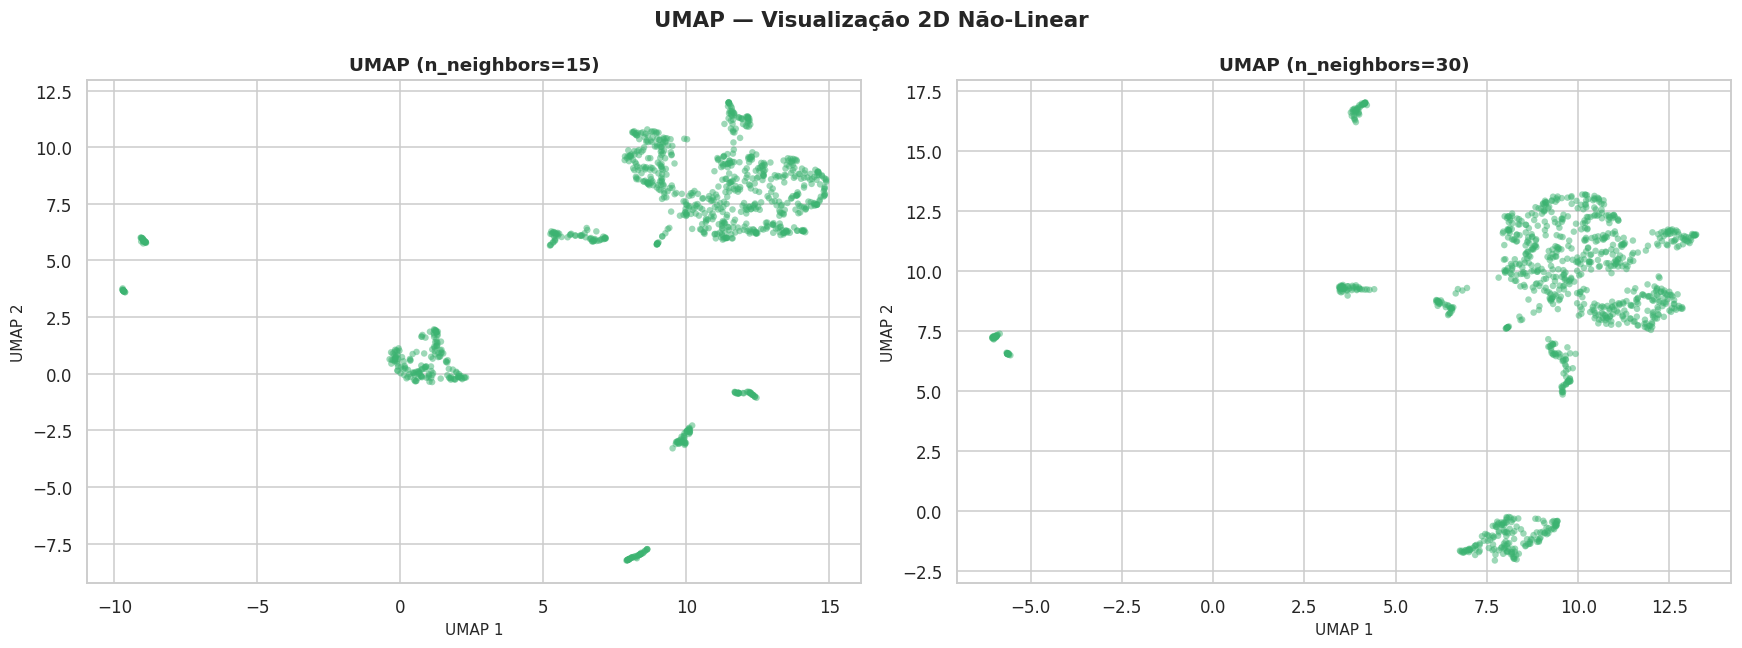

UMAP vs t-SNE: o UMAP tende a preservar melhor a estrutura global.
Clusters claramente separados no UMAP reforçam que a clusterização tem potencial neste dataset.


In [ ]:
# UMAP — testamos dois valores de n_neighbors
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, nn in zip(axes, [15, 30]):
    reducer = umap.UMAP(n_components=2, n_neighbors=nn,
                        min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_clean)

    ax.scatter(X_umap[:, 0], X_umap[:, 1],
               alpha=0.5, s=18, c='mediumseagreen', edgecolors='none')
    ax.set_title(f'UMAP (n_neighbors={nn})', fontsize=12, fontweight='bold')
    ax.set_xlabel('UMAP 1', fontsize=10)
    ax.set_ylabel('UMAP 2', fontsize=10)

plt.suptitle('UMAP — Visualização 2D Não-Linear', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('UMAP vs t-SNE: o UMAP tende a preservar melhor a estrutura global.')
print('Clusters claramente separados no UMAP reforçam que a clusterização tem potencial neste dataset.')

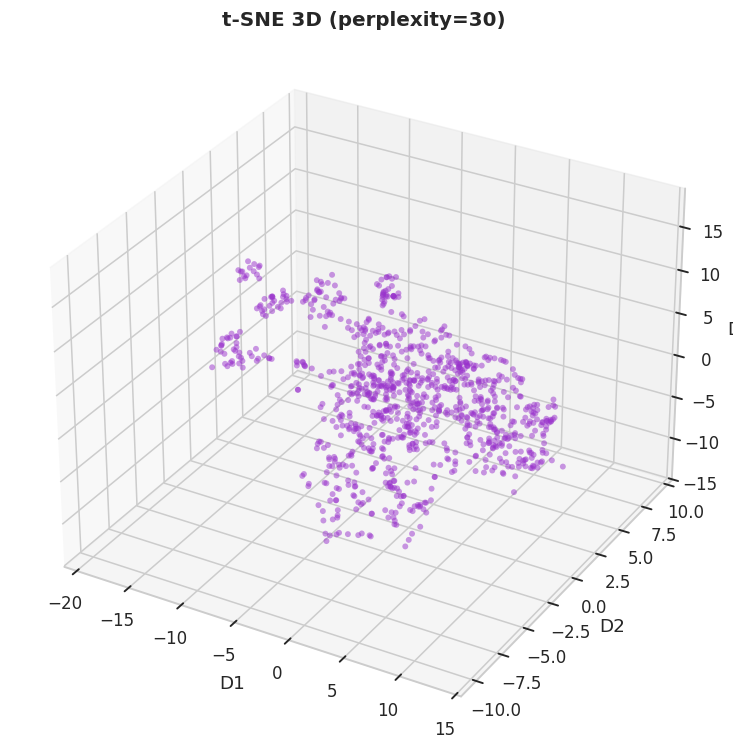

In [ ]:
# t-SNE 3D (visualização interativa com matplotlib)
from mpl_toolkits.mplot3d import Axes3D

tsne3 = TSNE(n_components=3, perplexity=30, n_iter=1000,
             random_state=42, learning_rate='auto', init='pca')
X_tsne3 = tsne3.fit_transform(X_clean)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_tsne3[:, 0], X_tsne3[:, 1], X_tsne3[:, 2],
                alpha=0.5, s=15, c='darkorchid', edgecolors='none')
ax.set_title('t-SNE 3D (perplexity=30)', fontsize=13, fontweight='bold')
ax.set_xlabel('D1'); ax.set_ylabel('D2'); ax.set_zlabel('D3')
plt.tight_layout()
plt.show()

---
## 7. Análise de Impacto das Métricas de Proximidade

**Justificativa:** A escolha da métrica de distância afeta diretamente como os algoritmos de clusterização
percebem similaridade. Analisamos o impacto de três métricas:

| Métrica | Fórmula | Sensibilidade | Indicada quando |
|---------|---------|---------------|-----------------|
| **Euclidiana** | √Σ(xᵢ−yᵢ)² | Alta a outliers e escala | Dados normalizados, clusters esféricos |
| **Manhattan** | Σ|xᵢ−yᵢ| | Mais robusta a outliers | Dados com distribuições assimétricas |
| **Cosine** | 1 − (x·y / ‖x‖‖y‖) | Direção, não magnitude | Dados com vetores de magnitude muito variável |

**Análise proposta:** comparar as distribuições de distâncias par-a-par entre as três métricas.

In [ ]:
# Amostramos todo o dataset
np.random.seed(42)
X_sample = X_clean.values

metrics = ['euclidean', 'manhattan', 'cosine']
dist_matrices = {m: pairwise_distances(X_sample, metric=m) for m in metrics}

# Extrair triângulo superior (sem diagonal)
upper_idx = np.triu_indices(len(X_sample), k=1)
dist_vals  = {m: dist_matrices[m][upper_idx] for m in metrics}

print('Estatísticas das distâncias par-a-par (amostra de 995 canais):')
stats_df = pd.DataFrame({
    m: {
        'Mínimo':  dist_vals[m].min(),
        'Mediana': np.median(dist_vals[m]),
        'Média':   dist_vals[m].mean(),
        'Máximo':  dist_vals[m].max(),
        'Desvio':  dist_vals[m].std(),
        'CV (%)':  dist_vals[m].std() / dist_vals[m].mean() * 100
    }
    for m in metrics
}).T
display(stats_df.round(4))

Estatísticas das distâncias par-a-par (amostra de 995 canais):


,Mínimo,Mediana,Média,Máximo,Desvio,CV (%)
euclidean,0.2264,3.9227,4.5061,21.5081,2.3920,53.0828
manhattan,0.4040,10.2002,11.8265,57.0719,6.4395,54.4495
cosine,0.0007,1.0161,0.9728,1.9237,0.3702,38.0581


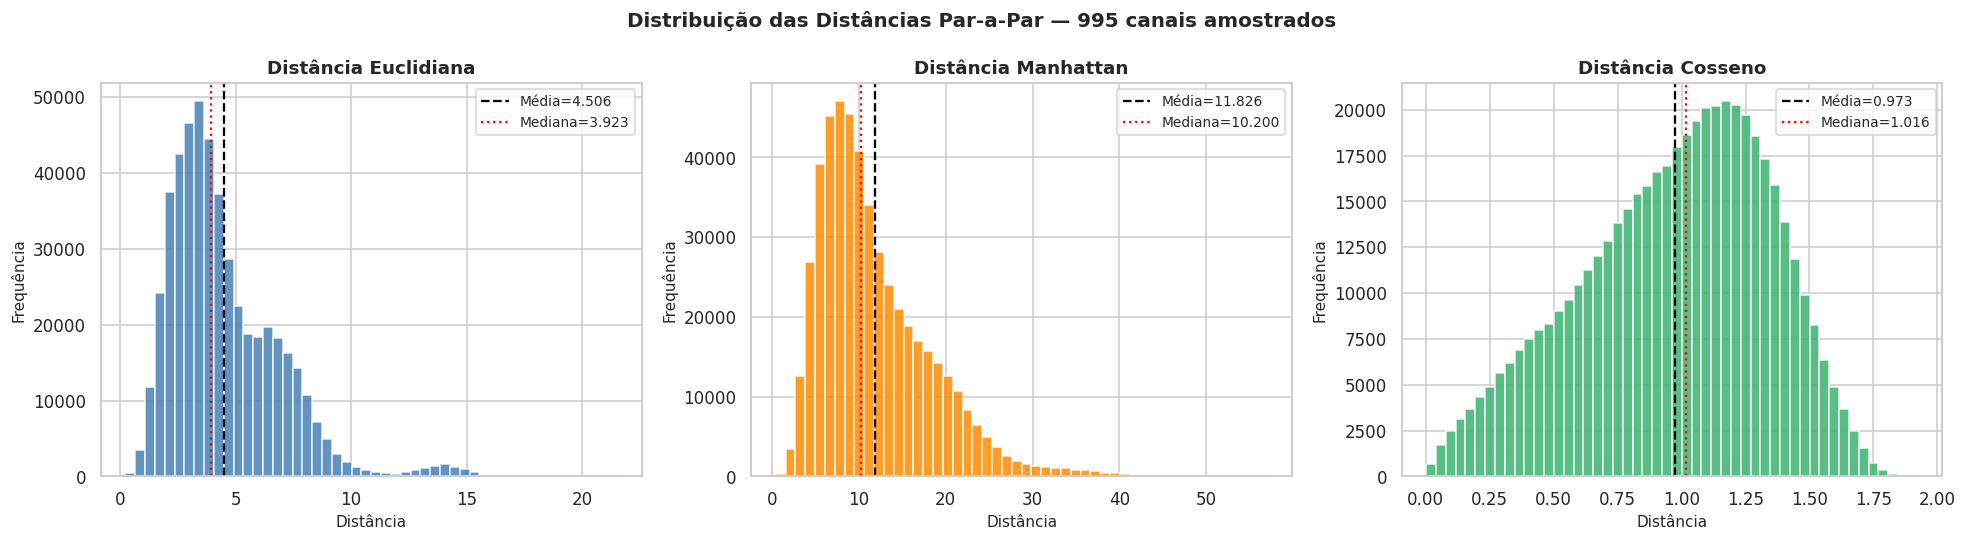

In [ ]:
# Distribuição das distâncias por métrica
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = {'euclidean': 'steelblue', 'manhattan': 'darkorange', 'cosine': 'mediumseagreen'}
labels  = {'euclidean': 'Euclidiana', 'manhattan': 'Manhattan', 'cosine': 'Cosseno'}

for ax, m in zip(axes, metrics):
    vals = dist_vals[m]
    ax.hist(vals, bins=50, color=palette[m], edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(vals),   color='black', linestyle='--', lw=1.5, label=f'Média={np.mean(vals):.3f}')
    ax.axvline(np.median(vals), color='red',   linestyle=':',  lw=1.5, label=f'Mediana={np.median(vals):.3f}')
    ax.set_title(f'Distância {labels[m]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Distância', fontsize=10)
    ax.set_ylabel('Frequência', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Distribuição das Distâncias Par-a-Par — 995 canais amostrados',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

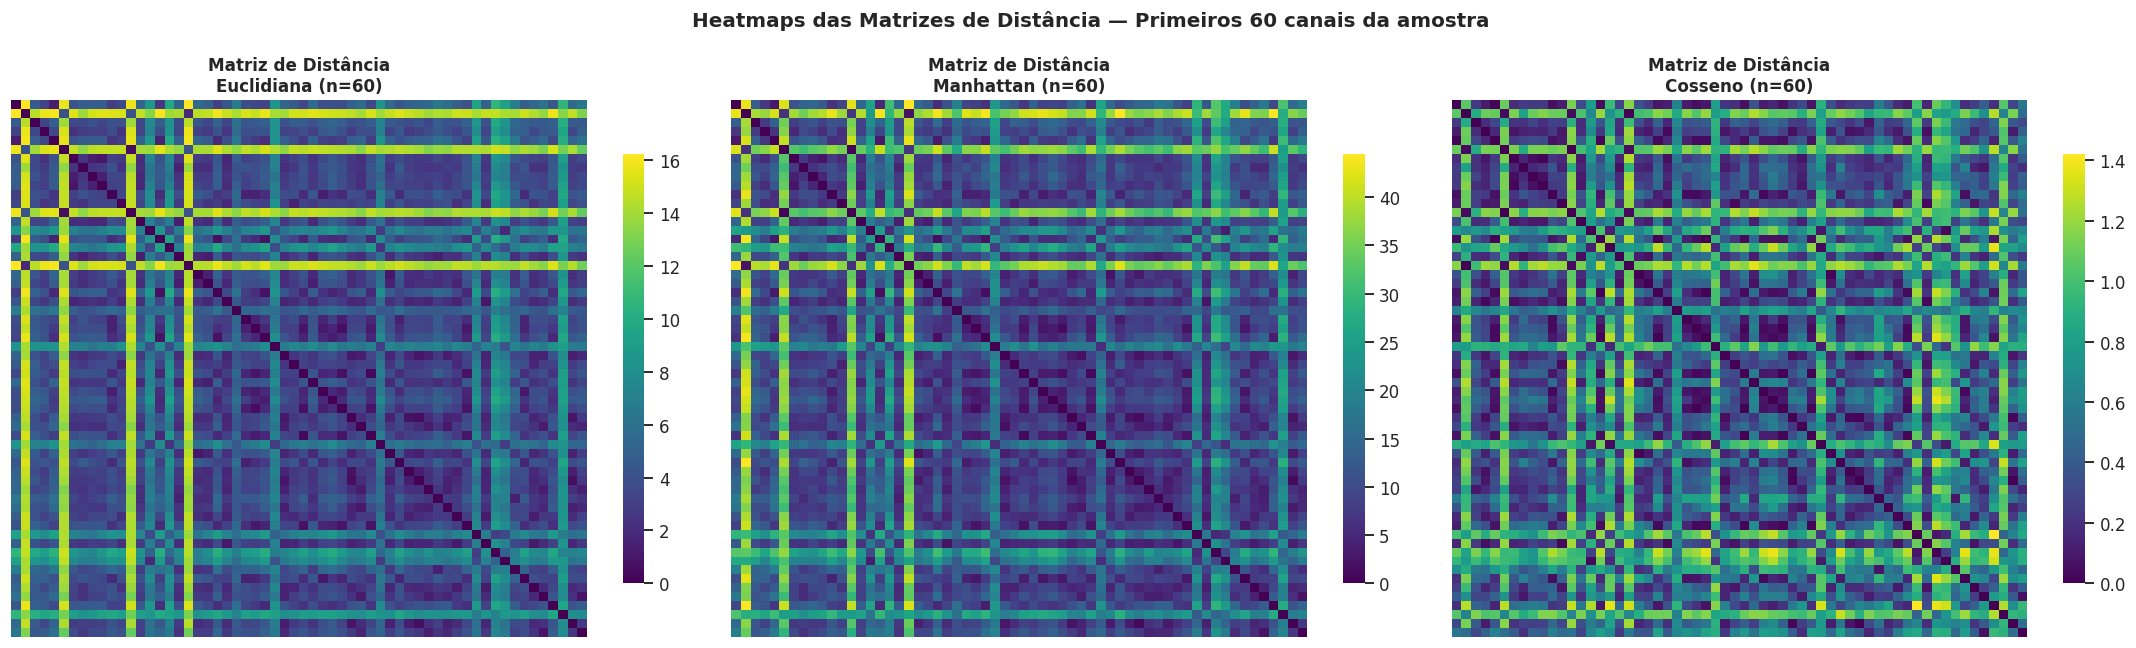

Interpretação:
  - Blocos escuros = canais próximos entre si (alta similaridade).
  - Padrão de blocos visível → estrutura de clusters existe nos dados.
  - Diferenças entre métricas indicam como cada uma captura a proximidade.


In [ ]:
# Heatmap das matrizes de distância (primeiros 60 canais para legibilidade)
n_vis = 60
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, m in zip(axes, metrics):
    dm = pairwise_distances(X_sample[:n_vis], metric=m)
    sns.heatmap(dm, ax=ax, cmap='viridis', xticklabels=False, yticklabels=False,
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'Matriz de Distância\n{labels[m]} (n={n_vis})',
                 fontsize=11, fontweight='bold')

plt.suptitle('Heatmaps das Matrizes de Distância — Primeiros 60 canais da amostra',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretação:')
print('  - Blocos escuros = canais próximos entre si (alta similaridade).')
print('  - Padrão de blocos visível → estrutura de clusters existe nos dados.')
print('  - Diferenças entre métricas indicam como cada uma captura a proximidade.')

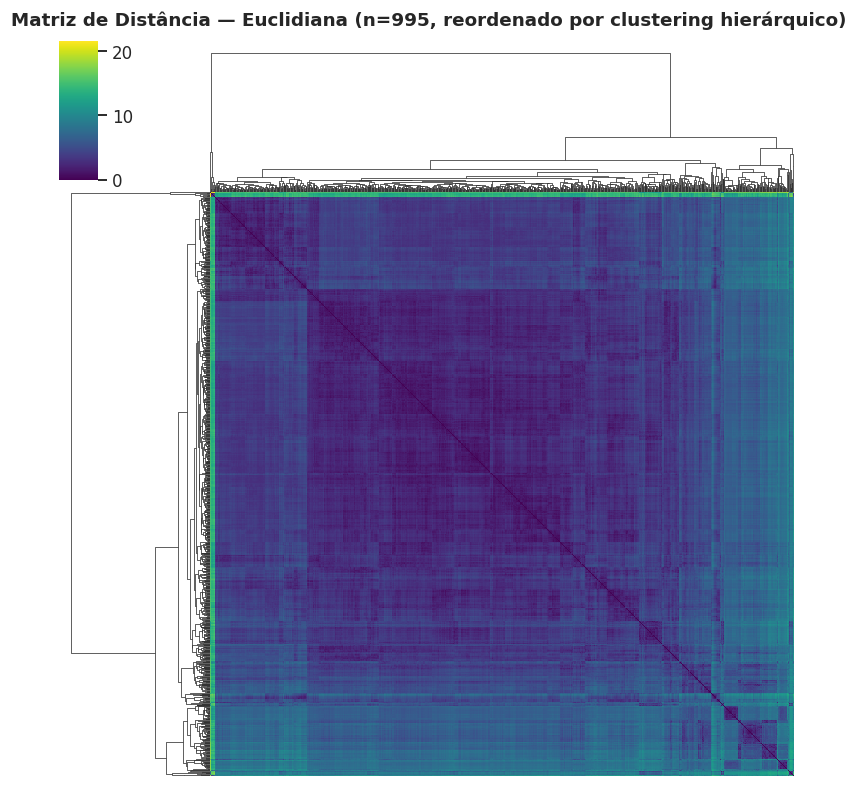

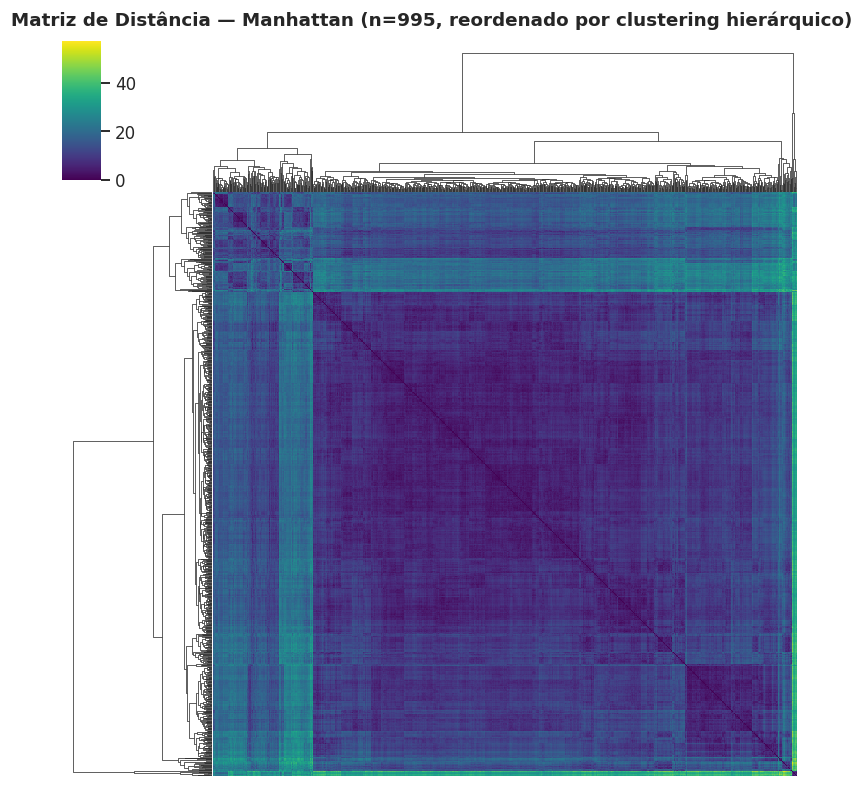

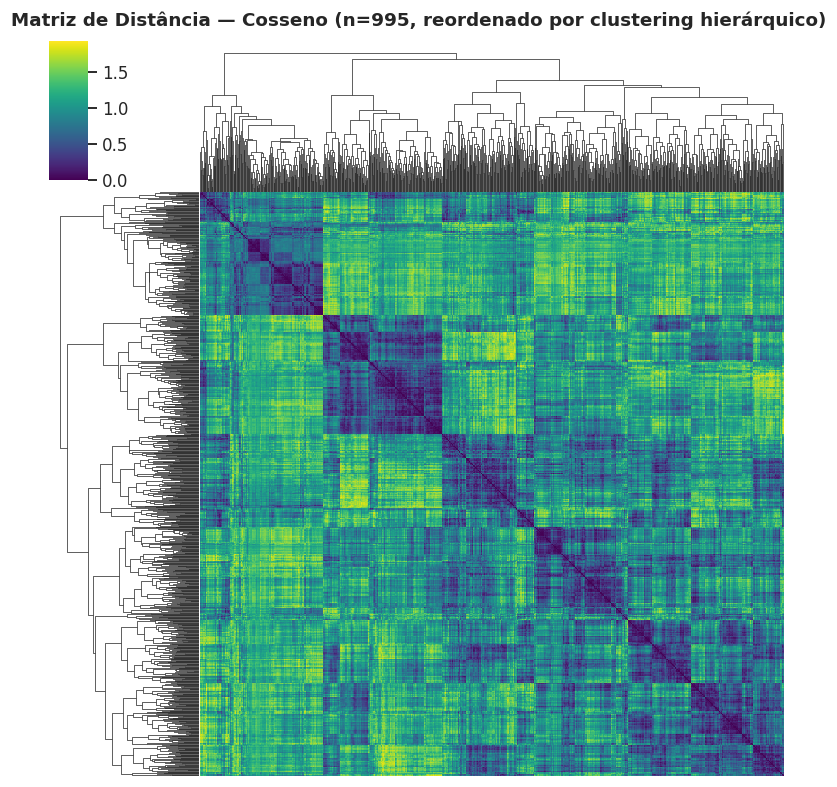

In [ ]:
from scipy.cluster.hierarchy import linkage, leaves_list

# Usar todos os 995 para o cálculo, mas plotar com clustermap que reordena
for m in metrics:
    dm_full = pairwise_distances(X_clean.values, metric=m)

    # clustermap reordena linhas/colunas para agrupar similares — muito mais informativo
    g = sns.clustermap(
        dm_full,
        cmap='viridis',
        xticklabels=False,
        yticklabels=False,
        figsize=(7, 7),
        cbar_kws={'shrink': 0.5}
    )
    g.fig.suptitle(f'Matriz de Distância — {labels[m]} (n=995, reordenado por clustering hierárquico)',
                   y=1.02, fontsize=12, fontweight='bold')
    plt.show()

In [ ]:
# Correlação entre as distâncias (as três métricas concordam entre si?)
from scipy.stats import spearmanr

print('Correlação de Spearman entre os rankings de distância par-a-par:')
for i, m1 in enumerate(metrics):
    for m2 in metrics[i+1:]:
        r, p = spearmanr(dist_vals[m1], dist_vals[m2])
        print(f'  {labels[m1]} × {labels[m2]}: r={r:.4f}  (p={p:.2e})')

print('\nInterpretação:')
print('  r > 0.9 → as métricas concordam no ranking de proximidade — escolha terá impacto menor.')
print('  r < 0.7 → as métricas divergem — a escolha da métrica afetará significativamente os clusters.')

Correlação de Spearman entre os rankings de distância par-a-par:
  Euclidiana × Manhattan: r=0.9754  (p=0.00e+00)
  Euclidiana × Cosseno: r=0.6099  (p=0.00e+00)
  Manhattan × Cosseno: r=0.6278  (p=0.00e+00)

Interpretação:
  r > 0.9 → as métricas concordam no ranking de proximidade — escolha terá impacto menor.
  r < 0.7 → as métricas divergem — a escolha da métrica afetará significativamente os clusters.


---
## 8. Resumo e Justificativas

### 8.1 Features Selecionadas

Das 28 variáveis originais, chegamos a **13 features numéricas** após:
- Remoção de identificadores (`rank`, `Youtuber`, `Title`, `Abbreviation`)
- Remoção de variáveis de data bruta (`created_year`, `created_month`, `created_date` → substituídas por `channel_age`)
- Remoção de variáveis altamente correlacionadas (|Spearman| ≥ 0.99):
  - Grupo de ganhos: mantido apenas `earnings_spread` e `highest_monthly_earnings`
  - `created_year` removido (correlação perfeita com `channel_age`)
  - `Urban_population` removido (r=0.995 com `Population`)

### 8.2 Correlação: Pearson vs Spearman

Spearman foi adotada como métrica principal de correlação pois:
- As variáveis apresentam alto *skewness* (distribuições muito assimétricas)
- Outliers extremos (T-Series, MrBeast) distorcem o Pearson
- Spearman é invariante a transformações monotônicas

### 8.3 PCA — Dimensões Retidas

O PCA revelou que **6 componentes** capturam 80% da variância
(de 13 features originais — redução de 7 dimensões, compressão de 54%).

Para a clusterização (Entrega 3), recomenda-se testar:
- Usar as 13 features originais normalizadas (com Euclidiana/Manhattan)
- Usar as **6 componentes** do PCA (reduz ruído e multicolinearidade residual)

### 8.4 Escolha da Métrica de Distância

Com base na análise da seção 7:
- **Euclidiana:** padrão para K-Means; sensível a outliers — mitigado pela normalização.
- **Manhattan:** mais robusta ao *skewness* residual — candidata alternativa para K-Medoids.
- **Cosine:** indicada se o foco for no perfil relativo do canal (não na magnitude absoluta).

A decisão final será tomada na Entrega 3 com base nas métricas de avaliação (Silhouette Score,
Davies-Bouldin e Calinski-Harabasz).

---
*Fim da Entrega 2*